### Example 1: Finite Difference Method Applied to the Lid Driven Cavity

The code solves the 2D incompressible Navier-Stokes equations for Newtonian fluids. Here is the continuity equation (conservation of mass):

$$\nabla \cdot \mathbf{u} = 0 \implies \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

The momentum equations are: 

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial x} + \nu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$$

$$\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = -\frac{1}{\rho} \frac{\partial p}{\partial y} + \nu \left( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \right)$$

Because pressure lacks an explicit transport equation, the solver decoupling algorithm splits the time step into sequential prediction and correction steps. In compressible flows the continuity equation can be used to determine the density. The pressure is then calculated from an equation of state. This approach is not appropriate for incompressible flows or low Mach number flows. Here, we will construct the pressure field so as to guarantee satisfaction of the continuity equation. It's strange, but it's possible. We are not interested in the absolute pressure—only the pressure gradients. The intermediate velocity prediction is defined as $\mathbf{u}^*$. We can use the following formula to calculate a tentative, non-divergence-free velocity field $\mathbf{u}^* = (u^*, v^*)$ by advancing advection and diffusion terms without the pressure gradient:

$$\frac{u_{i,j}^* - u_{i,j}^n}{\Delta t} = -\left( u^n \frac{\partial u^n}{\partial x} + v^n \frac{\partial u^n}{\partial y} \right) + \nu \left( \frac{\partial^2 u^n}{\partial x^2} + \frac{\partial^2 u^n}{\partial y^2} \right)$$

The true velocity $\mathbf{u}^{n+1}$ relates to $\mathbf{u}^*$ via the pressure gradient:

$$\mathbf{u}^{n+1} = \mathbf{u}^* - \frac{\Delta t}{\rho} \nabla p^{n+1}$$

Taking the divergence of both sides and enforcing continuity ($\nabla \cdot \mathbf{u}^{n+1} = 0$) yields the elliptic pressure Poisson equation:

$$\nabla^2 p^{n+1} = \frac{\rho}{\Delta t} (\nabla \cdot \mathbf{u}^*)$$

We can expand this into 2D Cartesian coordinates as:

$$\frac{\partial^2 p^{n+1}}{\partial x^2} + \frac{\partial^2 p^{n+1}}{\partial y^2} = \frac{\rho}{\Delta t} \left( \frac{\partial u^*}{\partial x} + \frac{\partial v^*}{\partial y} \right)$$

where the source term $b_{i,j}$ (on the right hand side) represents the velocity divergence of $\mathbf{u}^*$:

$$b_{i,j} = \frac{\rho}{\Delta t} \left( \frac{u_{i+1,j}^* - u_{i-1,j}^*}{2\Delta x} + \frac{v_{i,j+1}^* - v_{i,j-1}^*}{2\Delta y} \right)$$

We then correct the intermediate field using the computed pressure field to enforce mass conservation:

$$u_{i,j}^{n+1} = u_{i,j}^* - \frac{\Delta t}{\rho} \left( \frac{p_{i+1,j}^{n+1} - p_{i-1,j}^{n+1}}{2\Delta x} \right)$$

$$v_{i,j}^{n+1} = v_{i,j}^* - \frac{\Delta t}{\rho} \left( \frac{p_{i,j+1}^{n+1} - p_{i,j-1}^{n+1}}{2\Delta y} \right)$$

The derivatives are discretized on a collocated grid using 2nd-order central differencing schemes (CDS). The advection terms are:

$$u \frac{\partial u}{\partial x} \approx u_{i,j}^n \left( \frac{u_{i+1,j}^n - u_{i-1,j}^n}{2\Delta x} \right)$$

The diffusion terms are:

$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1,j}^n - 2u_{i,j}^n + u_{i-1,j}^n}{\Delta x^2}$$


Discretizing $\nabla^2 p = b$ using a 5-point finite difference stencil gives:

$$p_{i,j}^{(k+1)} = \frac{(p_{i+1,j}^{(k)} + p_{i-1,j}^{(k)})\Delta y^2 + (p_{i,j+1}^{(k)} + p_{i,j-1}^{(k)})\Delta x^2 - b_{i,j}\Delta x^2 \Delta y^2}{2(\Delta x^2 + \Delta y^2)}$$

which we can use as an iterative Poisson solver. Note that the index $k$ represents inner solver relaxation iterations, whereas $n$ represents physical time steps.

#### Stability Criteria

* Explicit time integration requires $\Delta t$ to satisfy diffusion stability:

$$\Delta t \le \frac{1}{2\nu \left( \frac{1}{\Delta x^2} + \frac{1}{\Delta y^2} \right)}$$

* Ensures advective domain of dependence is respected:

$$\text{CFL} = \Delta t \left( \frac{\vert{}u_{\text{max}}\vert{}}{\Delta x} + \frac{\vert{}v_{\text{max}}\vert{}}{\Delta y} \right) \le 1.0$$

* Keeps central differencing from developing unphysical non-linear wiggles:

$$Re_{\Delta x} = \frac{\vert{}u\vert{}\Delta x}{\nu} \le 2.0$$

### Algorithm

Here is how the algorithm works:
```
0. Pre-Loop Setup & Stability Checks (Initialization)
   • Define grid, fluid properties (ρ, ν), and boundary conditions
   • Verify safe fixed Δt via viscous limit and CFL condition (CFL ≤ 1.0)
   • Check cell Reynolds number (Re_Δx ≤ 2.0)
                │
                ▼
[ Start Main Time-Stepping Loop: Step n -> n+1 ]
                │
                ▼
1. Predict Intermediate Velocity (u*)
   • Advance advection & diffusion terms from u^n without ∇p
   • Calculate tentative velocity field u* and v*
                │
                ▼
2. Compute Divergence Source Term (b_ij)
   • Evaluate divergence source: b_ij = (ρ / Δt) * (∇ · u*)
                │
                ▼
3. Solve Pressure Poisson Equation (PPE)
   • Loop inner relaxation iterations (k -> k+1)
   • Update p^(k+1) using 5-point finite difference stencil
   • Iterate until pressure relaxation convergence is reached
   • Output solved pressure field p^(n+1)
                │
                ▼
4. Correct Velocity Field (u^(n+1))
   • u^(n+1) = u* - (Δt / ρ) * ∇p^(n+1)
   • Note: Correcting u* (rather than u^n) retains advection and diffusion
   • Guarantees non-divergent velocity field (∇ · u^(n+1) = 0)
                │
                ▼
5. State Update & Time Advance
   • Update memory grids: set u^n = u^(n+1) and v^n = v^(n+1)
   • Increment physical time (t = t + Δt) and step index (n = n + 1)
   • Loop back to Step 1 for next time step

```

=========== NUMERICAL STABILITY CHECK ============
CFL Number        : 0.2500   (Target <= 0.5)  -> [PASS]
Viscous dt Max    : 0.00063 s (Current: 0.00063 s) -> [PASS]
Cell Re (x / y)   : 1.00 / 0.00 (Target <= 2.0)  -> [PASS]
--------------------------------------------------
STATUS: STABLE — Safe to proceed with simulation.


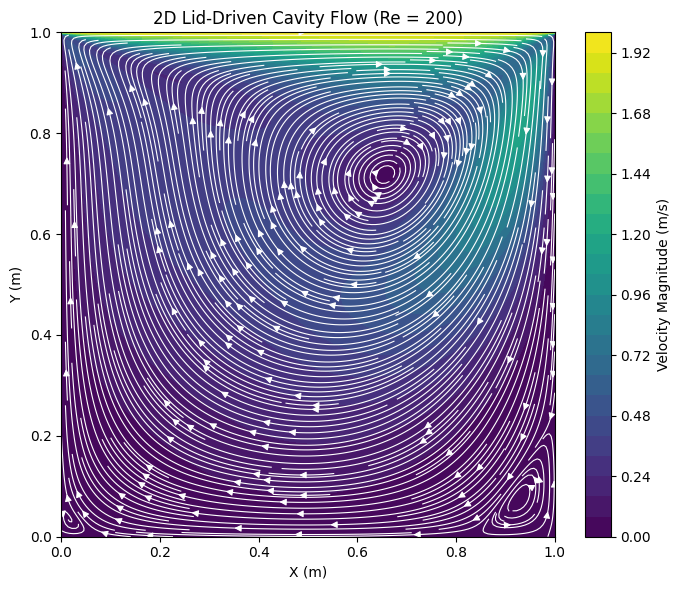

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. PHYSICAL & NUMERICAL PARAMETERS
# =============================================================================
Lx, Ly = 1, 1  # Domain size (m)
nx, ny = 201, 201  # Grid resolution (nodes in x and y)
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

rho = 1.0  # Density (kg/m^3)
nu = 0.01  # Kinematic viscosity (m^2/s) 
dt = 1.0 / (2.0 * nu * (1.0 / dx**2 + 1.0 / dy**2))
nt = 4000  # Total time steps
u_lid = 2  # Moving top lid velocity (m/s)

# Mesh generation
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# Field initialization
u = np.zeros((ny, nx))
v = np.zeros((ny, nx))
p = np.zeros((ny, nx))
b = np.zeros((ny, nx))

def check_stability(dx, dy, dt, nu, u_max=1.0, v_max=0.0):
    """Verifies CFL condition, viscous time-step limit, and Cell Reynolds numbers

    using existing simulation parameters.
    """
    # Stability calculations
    cfl = dt * (abs(u_max) / dx + abs(v_max) / dy)
    dt_viscous_max = 1.0 / (2.0 * nu * (1.0 / dx**2 + 1.0 / dy**2))
    re_dx = abs(u_max) * dx / nu
    re_dy = abs(v_max) * dy / nu
    re_cell_max = max(re_dx, re_dy)

    # Diagnostic Output
    print(f"{' NUMERICAL STABILITY CHECK ':=^50}")
    print(
        f"CFL Number        : {cfl:.4f}   (Target <= 0.5)  -> [{'PASS' if cfl <= 0.5 else 'WARN'}]"
    )
    print(
        f"Viscous dt Max    : {dt_viscous_max:.5f} s (Current: {dt:.5f} s) -> [{'PASS' if dt <= dt_viscous_max else 'FAIL'}]"
    )
    print(
        f"Cell Re (x / y)   : {re_dx:.2f} / {re_dy:.2f} (Target <= 2.0)  -> [{'PASS' if re_cell_max <= 2.0 else 'WARN'}]"
    )
    print("-" * 50)

    # Status summary
    if dt > dt_viscous_max or cfl > 1.0:
        print("STATUS: UNSTABLE — Solution will diverge (Floating-point NaN).")
    elif cfl > 0.5 or re_cell_max > 2.0:
        print(
            "STATUS: MARGINAL — Stable, but central differencing may show minor wiggles."
        )
    else:
        print("STATUS: STABLE — Safe to proceed with simulation.")
    print("=" * 50)


# Run check using existing parameters from your setup block
check_stability(dx, dy, dt, nu, u_max=u_lid)

# =============================================================================
# 2. PRESSURE POISSON SOLVER (JACOBI ITERATION)
# =============================================================================
def solve_pressure_poisson(p, b, dx, dy, nit=50):
    pn = np.empty_like(p)
    for _ in range(nit):
        pn[:] = p[:]
        p[1:-1, 1:-1] = (
            (pn[1:-1, 2:] + pn[1:-1, :-2]) * dy**2
            + (pn[2:, 1:-1] + pn[:-2, 1:-1]) * dx**2
            - b[1:-1, 1:-1] * (dx**2) * (dy**2)
        ) / (2 * (dx**2 + dy**2))

        # Boundary conditions: Neumann (dp/dn = 0) on all walls
        p[:, -1] = p[:, -2]  # Right wall
        p[:, 0] = p[:, 1]  # Left wall
        p[0, :] = p[1, :]  # Bottom wall
        p[-1, :] = p[-2, :]  # Top wall (lid)


    return p


# =============================================================================
# 3. MAIN TIME-STEPPING LOOP
# =============================================================================
for n in range(nt):
    un = u.copy()
    vn = v.copy()

    '''
    # Step A: Intermediate Velocity Field (Advection + Diffusion)
    u[1:-1, 1:-1] = un[1:-1, 1:-1] - dt * (
        un[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[1:-1, :-2]) / dx
        + vn[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[:-2, 1:-1]) / dy
    ) + nu * dt * (
        (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, :-2]) / dx**2
        + (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[:-2, 1:-1]) / dy**2
    )

    v[1:-1, 1:-1] = vn[1:-1, 1:-1] - dt * (
        un[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[1:-1, :-2]) / dx
        + vn[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[:-2, 1:-1]) / dy
    ) + nu * dt * (
        (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, :-2]) / dx**2
        + (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[:-2, 1:-1]) / dy**2
    )
    '''

    # Step A: Intermediate Velocity Field using 2nd-Order Central Differencing (CDS)
    u[1:-1, 1:-1] = (
        un[1:-1, 1:-1]
        - dt
        * (
            un[1:-1, 1:-1] * (un[1:-1, 2:] - un[1:-1, :-2]) / (2 * dx)
            + vn[1:-1, 1:-1] * (un[2:, 1:-1] - un[:-2, 1:-1]) / (2 * dy)
        )
        + nu
        * dt
        * (
            (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, :-2]) / dx**2
            + (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[:-2, 1:-1]) / dy**2
        )
    )
    
    v[1:-1, 1:-1] = (
        vn[1:-1, 1:-1]
        - dt
        * (
            un[1:-1, 1:-1] * (vn[1:-1, 2:] - vn[1:-1, :-2]) / (2 * dx)
            + vn[1:-1, 1:-1] * (vn[2:, 1:-1] - vn[:-2, 1:-1]) / (2 * dy)
        )
        + nu
        * dt
        * (
            (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, :-2]) / dx**2
            + (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[:-2, 1:-1]) / dy**2
        )
    )

    # Step B: Apply No-Slip and Lid Velocity Boundary Conditions
    u[0, :] = 0.0  # Bottom
    u[:, 0] = 0.0  # Left
    u[:, -1] = 0.0  # Right
    u[-1, :] = u_lid  # Top Lid (Moving)

    v[0, :] = 0.0  # Bottom
    v[:, 0] = 0.0  # Left
    v[:, -1] = 0.0  # Right
    v[-1, :] = 0.0  # Top Lid

    # Step C: Source term for Pressure Poisson Equation (Divergence of u*)
    b[1:-1, 1:-1] = (rho / dt) * (
        (u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx)
        + (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy)
    )

    # Step D: Solve Pressure Poisson Equation
    p = solve_pressure_poisson(p, b, dx, dy, nit=50)

    # Step E: Velocity Correction (Project onto divergence-free space)
    u[1:-1, 1:-1] -= (dt / rho) * (p[1:-1, 2:] - p[1:-1, :-2]) / (2 * dx)
    v[1:-1, 1:-1] -= (dt / rho) * (p[2:, 1:-1] - p[:-2, 1:-1]) / (2 * dy)

    # Re-enforce Velocity Boundary Conditions
    u[0, :] = 0.0
    u[:, 0] = 0.0
    u[:, -1] = 0.0
    u[-1, :] = u_lid

    v[0, :] = 0.0
    v[:, 0] = 0.0
    v[:, -1] = 0.0
    v[-1, :] = 0.0

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
vel_mag = np.sqrt(u**2 + v**2)

plt.figure(figsize=(7, 6), dpi=100)
plt.contourf(X, Y, vel_mag, levels=30, cmap="viridis")
plt.colorbar(label="Velocity Magnitude (m/s)")
plt.streamplot(X, Y, u, v, color="white", linewidth=0.8, density=4)
plt.title(
    f"2D Lid-Driven Cavity Flow (Re = {int(u_lid * Lx / nu)})", fontsize=12
)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.tight_layout()
plt.show()